In [99]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [100]:
db=pd.read_csv("datasetler/StudentsPerformance.csv")

In [101]:
db.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [102]:
db.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [103]:
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [104]:
db["parental level of education"].unique()

array(["bachelor's degree", 'some college', "master's degree",
       "associate's degree", 'high school', 'some high school'],
      dtype=object)

In [105]:
egitim_siralamasi = {
    'some high school': 0,     # Lise terk / bazı lise dersleri
    'high school': 1,          # Lise mezunu
    'some college': 2,         # Üniversite terk / ön lisans öncesi
    "associate's degree": 3,   # Ön lisans
    "bachelor's degree": 4,    # Lisans
    "master's degree": 5       # Yüksek Lisans
}

In [106]:
db['education_encoded'] = db['parental level of education'].map(egitim_siralamasi)

In [107]:
db.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,education_encoded
0,female,group B,bachelor's degree,standard,none,72,72,74,4
1,female,group C,some college,standard,completed,69,90,88,2
2,female,group B,master's degree,standard,none,90,95,93,5
3,male,group A,associate's degree,free/reduced,none,47,57,44,3
4,male,group C,some college,standard,none,76,78,75,2


In [108]:
db.drop("parental level of education",axis=1,inplace=True)

In [109]:
db.head()

,gender,race/ethnicity,lunch,test preparation course,math score,reading score,writing score,education_encoded
0,female,group B,standard,none,72,72,74,4
1,female,group C,standard,completed,69,90,88,2
2,female,group B,standard,none,90,95,93,5
3,male,group A,free/reduced,none,47,57,44,3
4,male,group C,standard,none,76,78,75,2


In [110]:
# One-Hot Encoding (Tek sütun kalacak şekilde)
db = pd.get_dummies(db, columns=['gender'], drop_first=True, dtype=int)
#drop first ile gender sütununu siliyorum ve tek sütunda 0 ve 1 ile karar veriyorum cinsiyete

In [111]:
db.head(10)

,race/ethnicity,lunch,test preparation course,math score,reading score,writing score,education_encoded,gender_male
0,group B,standard,none,72,72,74,4,0
1,group C,standard,completed,69,90,88,2,0
2,group B,standard,none,90,95,93,5,0
3,group A,free/reduced,none,47,57,44,3,1
4,group C,standard,none,76,78,75,2,1
5,group B,standard,none,71,83,78,3,0
6,group B,standard,completed,88,95,92,2,0
7,group B,free/reduced,none,40,43,39,2,1
8,group D,free/reduced,completed,64,64,67,1,1
9,group B,free/reduced,none,38,60,50,1,0


In [112]:
db["test preparation course"].unique()

array(['none', 'completed'], dtype=object)

In [113]:
db['test_prep_encoded'] = db['test preparation course'].map({'none': 0, 'completed': 1})

In [114]:
db.head()

,race/ethnicity,lunch,test preparation course,math score,reading score,writing score,education_encoded,gender_male,test_prep_encoded
0,group B,standard,none,72,72,74,4,0,0
1,group C,standard,completed,69,90,88,2,0,1
2,group B,standard,none,90,95,93,5,0,0
3,group A,free/reduced,none,47,57,44,3,1,0
4,group C,standard,none,76,78,75,2,1,0


In [115]:
db.drop("test preparation course",axis=1,inplace=True)

In [116]:
db.head()

,race/ethnicity,lunch,math score,reading score,writing score,education_encoded,gender_male,test_prep_encoded
0,group B,standard,72,72,74,4,0,0
1,group C,standard,69,90,88,2,0,1
2,group B,standard,90,95,93,5,0,0
3,group A,free/reduced,47,57,44,3,1,0
4,group C,standard,76,78,75,2,1,0


In [117]:
db["lunch"].unique()

array(['standard', 'free/reduced'], dtype=object)

In [118]:
db['lunch'] = db['lunch'].replace({'free/reduced': 0, 'standard': 1})

C:\Users\HASAN\AppData\Local\Temp\ipykernel_9208\2812796731.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  db['lunch'] = db['lunch'].replace({'free/reduced': 0, 'standard': 1})


In [119]:
db.head(10)

,race/ethnicity,lunch,math score,reading score,writing score,education_encoded,gender_male,test_prep_encoded
0,group B,1,72,72,74,4,0,0
1,group C,1,69,90,88,2,0,1
2,group B,1,90,95,93,5,0,0
3,group A,0,47,57,44,3,1,0
4,group C,1,76,78,75,2,1,0
5,group B,1,71,83,78,3,0,0
6,group B,1,88,95,92,2,0,1
7,group B,0,40,43,39,2,1,0
8,group D,0,64,64,67,1,1,1
9,group B,0,38,60,50,1,0,0


In [120]:
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   race/ethnicity     1000 non-null   object
 1   lunch              1000 non-null   int64 
 2   math score         1000 non-null   int64 
 3   reading score      1000 non-null   int64 
 4   writing score      1000 non-null   int64 
 5   education_encoded  1000 non-null   int64 
 6   gender_male        1000 non-null   int64 
 7   test_prep_encoded  1000 non-null   int64 
dtypes: int64(7), object(1)
memory usage: 62.6+ KB


In [121]:
db["race/ethnicity"].unique()

array(['group B', 'group C', 'group A', 'group D', 'group E'],
      dtype=object)

In [122]:
# race/ethnicity sütununu One-Hot Encoding yapıyoruz
# dtype=int ile 0 ve 1 olarak alıyoruz
db = pd.get_dummies(db, columns=['race/ethnicity'], prefix='race', drop_first=True, dtype=int)
#tüm gruplar sıfır ise a grubuna ait old. anlaşılır bu sayede 1 sütun eksiltmiş olduk.

In [123]:
db.head()

,lunch,math score,reading score,writing score,education_encoded,gender_male,test_prep_encoded,race_group B,race_group C,race_group D,race_group E
0,1,72,72,74,4,0,0,1,0,0,0
1,1,69,90,88,2,0,1,0,1,0,0
2,1,90,95,93,5,0,0,1,0,0,0
3,0,47,57,44,3,1,0,0,0,0,0
4,1,76,78,75,2,1,0,0,1,0,0


In [124]:
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   lunch              1000 non-null   int64
 1   math score         1000 non-null   int64
 2   reading score      1000 non-null   int64
 3   writing score      1000 non-null   int64
 4   education_encoded  1000 non-null   int64
 5   gender_male        1000 non-null   int64
 6   test_prep_encoded  1000 non-null   int64
 7   race_group B       1000 non-null   int64
 8   race_group C       1000 non-null   int64
 9   race_group D       1000 non-null   int64
 10  race_group E       1000 non-null   int64
dtypes: int64(11)
memory usage: 86.1 KB


In [139]:
db['average_score'] = (db['math score'] + db['reading score'] + db['writing score']) / 3

In [140]:
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   lunch              1000 non-null   int64  
 1   math score         1000 non-null   int64  
 2   reading score      1000 non-null   int64  
 3   writing score      1000 non-null   int64  
 4   education_encoded  1000 non-null   int64  
 5   gender_male        1000 non-null   int64  
 6   test_prep_encoded  1000 non-null   int64  
 7   race_group B       1000 non-null   int64  
 8   race_group C       1000 non-null   int64  
 9   race_group D       1000 non-null   int64  
 10  race_group E       1000 non-null   int64  
 11  average_score      1000 non-null   float64
dtypes: float64(1), int64(11)
memory usage: 93.9 KB


In [127]:
X=db[["lunch","education_encoded","gender_male","test_prep_encoded","race_group B","race_group C","race_group D","race_group E"]]
y=db["average_score"]

In [128]:
db.head()

,lunch,math score,reading score,writing score,education_encoded,gender_male,test_prep_encoded,race_group B,race_group C,race_group D,race_group E,average_score
0,1,72,72,74,4,0,0,1,0,0,0,72.666667
1,1,69,90,88,2,0,1,0,1,0,0,82.333333
2,1,90,95,93,5,0,0,1,0,0,0,92.666667
3,0,47,57,44,3,1,0,0,0,0,0,49.333333
4,1,76,78,75,2,1,0,0,1,0,0,76.333333


In [129]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20, random_state=25)

In [130]:
import pickle

In [131]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score


In [132]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [133]:
y_pred = model.predict(X_test)
print(f"R2 Skoru: {r2_score(y_test, y_pred)}")
print(f"Hata Payı (MAE): {mean_absolute_error(y_test, y_pred)}")

R2 Skoru: 0.011770193897586934
Hata Payı (MAE): 12.105459637912485


<Axes: >

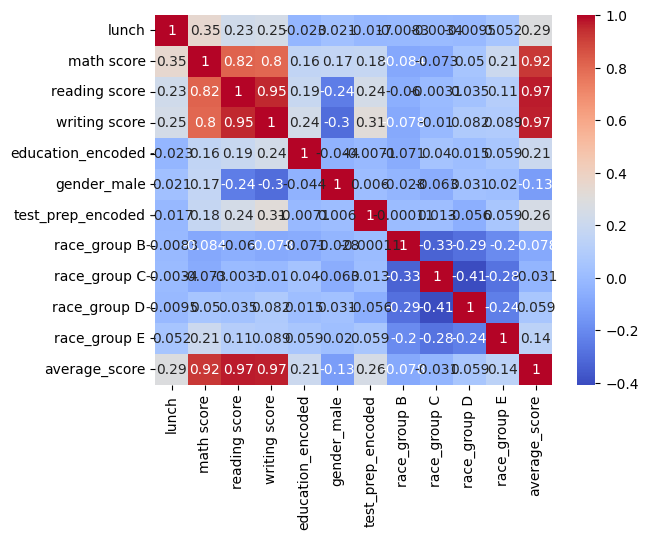

In [134]:
sns.heatmap(db.corr(), annot=True, cmap='coolwarm')

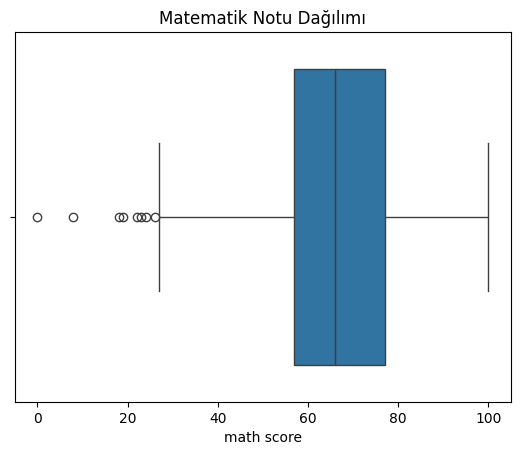

In [135]:
sns.boxplot(x=db['math score'])
plt.title('Matematik Notu Dağılımı')
plt.show()

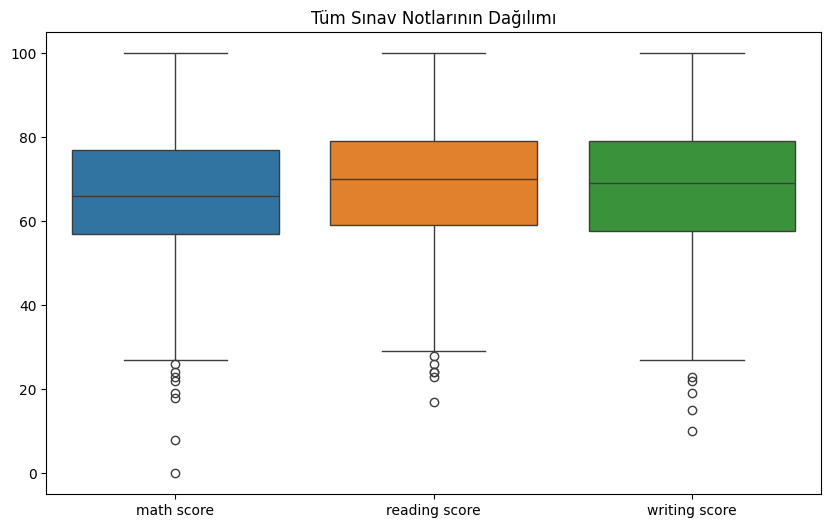

In [137]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=db[['math score', 'reading score', 'writing score']])
plt.title('Tüm Sınav Notlarının Dağılımı')
plt.show()

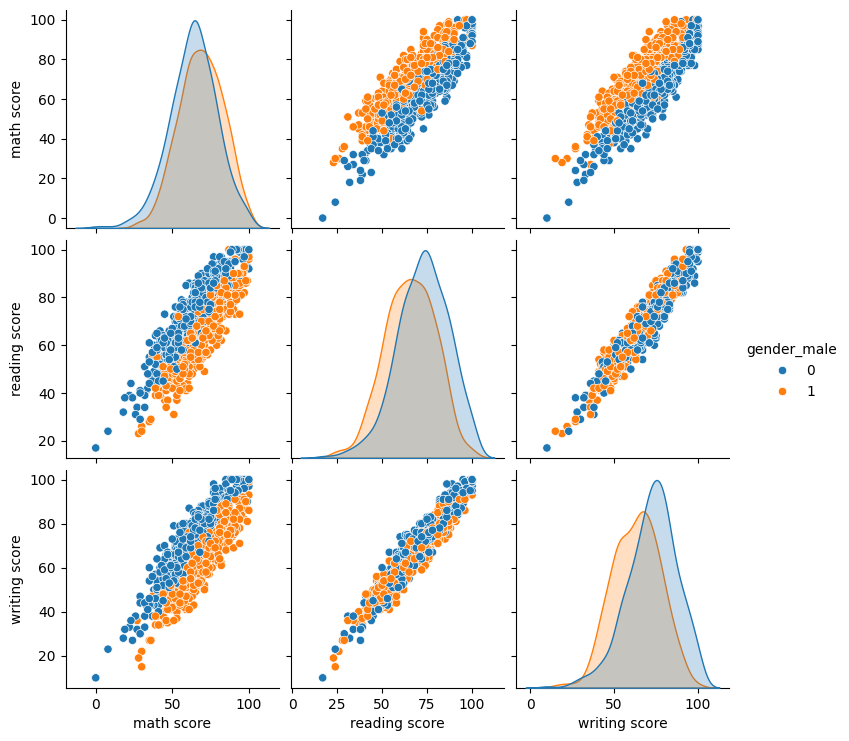

In [146]:
cols = ['math score', 'reading score', 'writing score', 'gender_male']

# Pairplot oluşturalım
# 'hue' parametresi ile veriyi cinsiyete göre renklendiriyoruz
sns.pairplot(db[cols], hue='gender_male')

In [143]:
db.head()

,lunch,math score,reading score,writing score,education_encoded,gender_male,test_prep_encoded,race_group B,race_group C,race_group D,race_group E,average_score
0,1,72,72,74,4,0,0,1,0,0,0,72.666667
1,1,69,90,88,2,0,1,0,1,0,0,82.333333
2,1,90,95,93,5,0,0,1,0,0,0,92.666667
3,0,47,57,44,3,1,0,0,0,0,0,49.333333
4,1,76,78,75,2,1,0,0,1,0,0,76.333333


<Axes: xlabel='math score', ylabel='Count'>

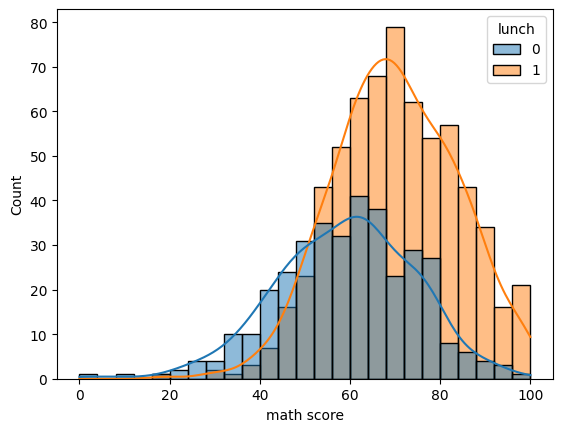

In [150]:
sns.histplot(data=db, x="math score", hue="lunch", kde=True)

In [152]:
sns.pairplot(data=db, x="math score", hue="lunch")

TypeError: pairplot() got an unexpected keyword argument 'x'